## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (aggregate, export, fit_scaler, load_train,
                       merge_faults, plot_bars, plot_cv,
                       plot_means, plot_stds, run_spectra,
                       versions)

print(versions())

/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 14


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Von hier gehen die Werte als Argumente in die Funktionsaufrufe. Was
# nicht gesetzt wird, bleibt auf dem Default der jeweiligen Funktion
# (pre_fault_cutoff=21, plot_mode='linear', ncols=6, ...).
# RUNS_PER_FAULT=3 kuerzt auf drei Laeufe je Fault - ein Probelauf von
# Minuten statt Stunden.

METHOD = "dyca"
SCALING_MODE = "global_mean"
DATA_DIR = "data_csv"           # Ordner mit den vier TEP-CSVs
RUNS_PER_FAULT = None           # None = alle 500 Runs je Fault

# DyCA-Stufe: m lineare Komponenten, n Dimension des
# deterministischen Systems. Randbedingungen des Pakets:
# n >= m und m >= n - m. Die Schaetzzelle unten hilft bei
# der Wahl.
DYCA_M = 2
DYCA_N = 4

K_MAX = 10
K_BAR = 10


## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen in DATA_DIR liegen. Sie werden EINMAL
# gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt; die
# Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(data_dir=DATA_DIR,
                              runs_per_fault=RUNS_PER_FAULT)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(METHOD, SCALING_MODE, DATA_DIR)

  lese TEP_FaultFree_Training.csv ...


  lese TEP_Faulty_Training.csv ...


  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52


  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


## m und n schätzen

DyCA braucht zwei Vorgaben: *m* lineare Komponenten und *n* als Dimension des deterministischen Systems. Beide sollten aus den Normalbetriebsdaten abgelesen werden, nicht geraten. Die zwei Diagnoseplots darunter zeigen, was die Daten nahelegen.

Referenz-Run shape: (500, 52)


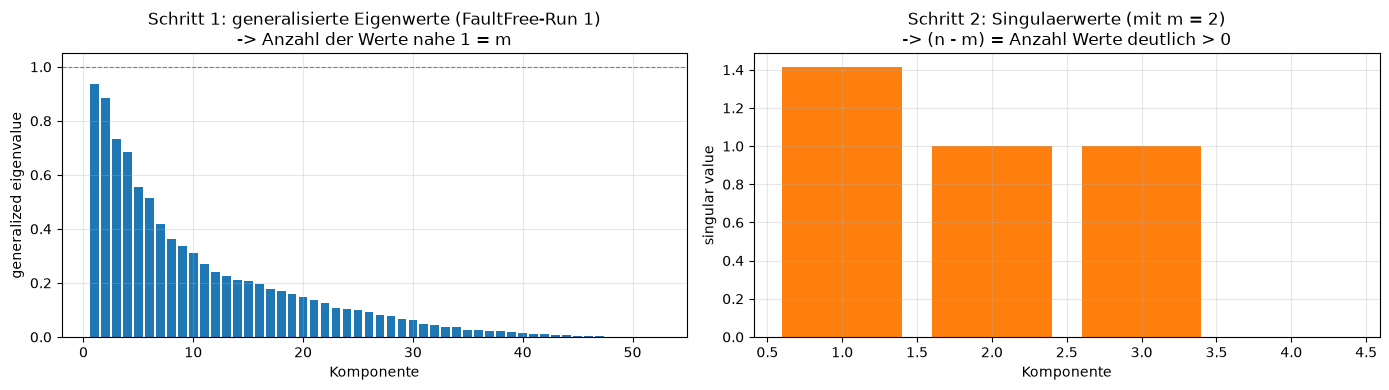


Aktuelle Einstellung: dyca_m = 2, dyca_n = 4
Legen die Plots eine andere Wahl nahe, in der Konfigurations-zelle aendern und neu ausfuehren.


In [4]:
# ============================================================
# m und n aus den FaultFree-Daten schaetzen
# ============================================================
# Links: generalisierte Eigenwerte ohne m-Vorgabe - die Anzahl der Werte
# nahe 1 ist das gesuchte m. Rechts: Singulaerwerte bei vorgegebenem m -
# die Anzahl der deutlich von null verschiedenen Werte ist (n - m).
# Der Referenzlauf wird mit DEMSELBEN scaling_mode vorverarbeitet wie die
# Produktivschleife, Schaetzung und Lauf koennen also nicht auseinander-
# driften.
from tep.eigen import plot_dyca_mn_estimate

_ = plot_dyca_mn_estimate(df_ff, SCALING_MODE, scaler,
                          dyca_m=DYCA_M, dyca_n=DYCA_N)

## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [5]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(df_all, METHOD, scaling_mode=SCALING_MODE,
                      scaler=scaler,
                      dyca_m=DYCA_M, dyca_n=DYCA_N)

per_run.head()

Berechne DyCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Berechne DyCA-Spektrum pro Run:   0%|          | 32/10500 [00:00<00:33, 315.65it/s]

Berechne DyCA-Spektrum pro Run:   1%|          | 64/10500 [00:00<00:46, 224.66it/s]

Berechne DyCA-Spektrum pro Run:   1%|          | 110/10500 [00:00<00:33, 311.42it/s]

Berechne DyCA-Spektrum pro Run:   1%|▏         | 157/10500 [00:00<00:28, 366.03it/s]

...

Berechne DyCA-Spektrum pro Run: 100%|█████████▉| 10448/10500 [00:41<00:00, 319.91it/s]

Berechne DyCA-Spektrum pro Run: 100%|█████████▉| 10481/10500 [00:41<00:00, 317.76it/s]

Berechne DyCA-Spektrum pro Run: 100%|██████████| 10500/10500 [00:41<00:00, 252.97it/s]

Erfolgreiche Runs: 10073
Uebersprungen   : 0 (weniger als 9 Samples)
Fehler          : 427
Erste Fehler:
  fault=0, run=12: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=55: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=63: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=91: Complex eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=107: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.


,faultNumber,simulationRun,dyca_1,dyca_2,dyca_3,dyca_4,dyca_5,dyca_6,dyca_7,dyca_8,...,dyca_43,dyca_44,dyca_45,dyca_46,dyca_47,dyca_48,dyca_49,dyca_50,dyca_51,dyca_52
0,0,1,0.938135,0.883932,0.732372,0.685321,0.553840,0.514848,0.418449,0.362320,...,0.007477,0.007182,0.004298,0.003295,0.002371,0.001370,0.000447,0.000079,0.000008,0.000005
1,0,2,0.951969,0.930104,0.804479,0.755123,0.531488,0.501349,0.433419,0.402186,...,0.005910,0.005220,0.004508,0.003610,0.002911,0.001903,0.000934,0.000409,0.000246,0.000029
2,0,3,0.931521,0.906700,0.735948,0.715483,0.534502,0.494144,0.413665,0.396510,...,0.007347,0.006405,0.004387,0.003681,0.002929,0.001494,0.001289,0.000047,0.000008,0.000002
3,0,4,0.934332,0.906980,0.774787,0.676035,0.573521,0.499902,0.430269,0.400309,...,0.009028,0.006163,0.005838,0.004477,0.002627,0.001968,0.001028,0.000696,0.000089,0.000001
4,0,5,0.938610,0.878738,0.784147,0.625218,0.530511,0.481130,0.469799,0.413852,...,0.007265,0.006788,0.005567,0.004285,0.003754,0.002599,0.001469,0.000466,0.000053,0.000022


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [6]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(per_run, METHOD)

agg.head()

Aggregierte DyCA-Statistiken pro Fault: (21, 105)


,faultNumber,dyca_1_mean,dyca_1_std,dyca_2_mean,dyca_2_std,dyca_3_mean,dyca_3_std,dyca_4_mean,dyca_4_std,dyca_5_mean,...,dyca_48_mean,dyca_48_std,dyca_49_mean,dyca_49_std,dyca_50_mean,dyca_50_std,dyca_51_mean,dyca_51_std,dyca_52_mean,dyca_52_std
0,0,0.931760,0.008280,0.891126,0.017871,0.762867,0.027814,0.668095,0.036317,0.534843,...,0.001370,0.000521,0.000746,0.000379,0.000313,0.000202,0.000086,0.000078,0.000009,0.000016
1,1,0.984899,0.002502,0.957351,0.004751,0.932616,0.007176,0.817774,0.015742,0.709583,...,0.001481,0.000562,0.000822,0.000396,0.000369,0.000232,0.000109,0.000102,0.000014,0.000025
2,2,0.944520,0.005474,0.911113,0.011024,0.812270,0.021633,0.706364,0.023842,0.556140,...,0.001478,0.000521,0.000826,0.000367,0.000376,0.000223,0.000124,0.000107,0.000015,0.000026
3,3,0.932782,0.008303,0.893427,0.017937,0.766368,0.027799,0.673325,0.035784,0.540930,...,0.001436,0.000522,0.000799,0.000370,0.000344,0.000226,0.000097,0.000091,0.000011,0.000020
4,4,0.932542,0.008281,0.893404,0.017942,0.771132,0.027554,0.677857,0.033026,0.580106,...,0.001495,0.000558,0.000827,0.000393,0.000354,0.000231,0.000101,0.000095,0.000010,0.000017


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

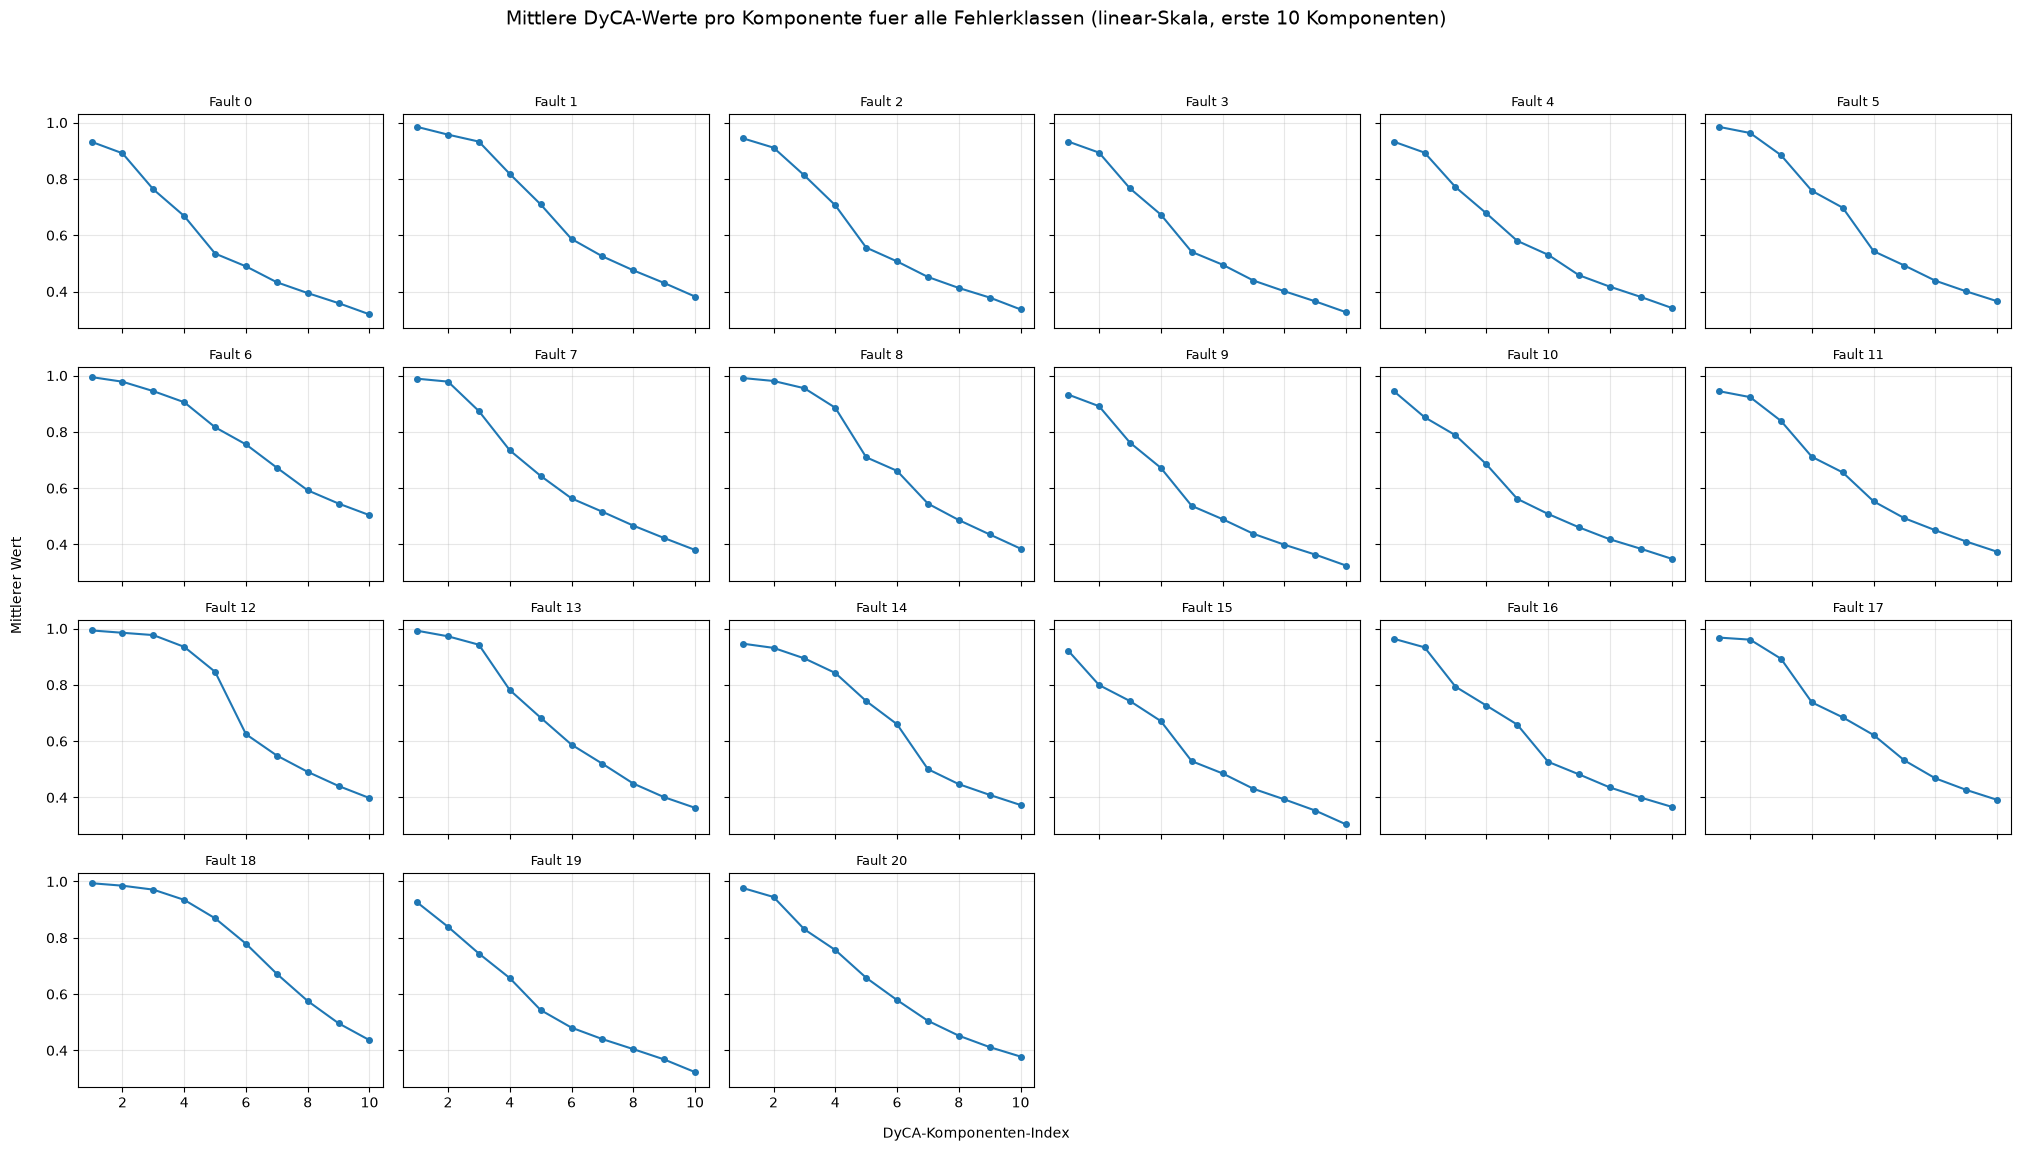

In [7]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert plot_mode
# ("linear" | "log" | "relative"), die Zahl der gezeigten Komponenten
# K_MAX.
_ = plot_means(agg, METHOD, k_max=K_MAX)

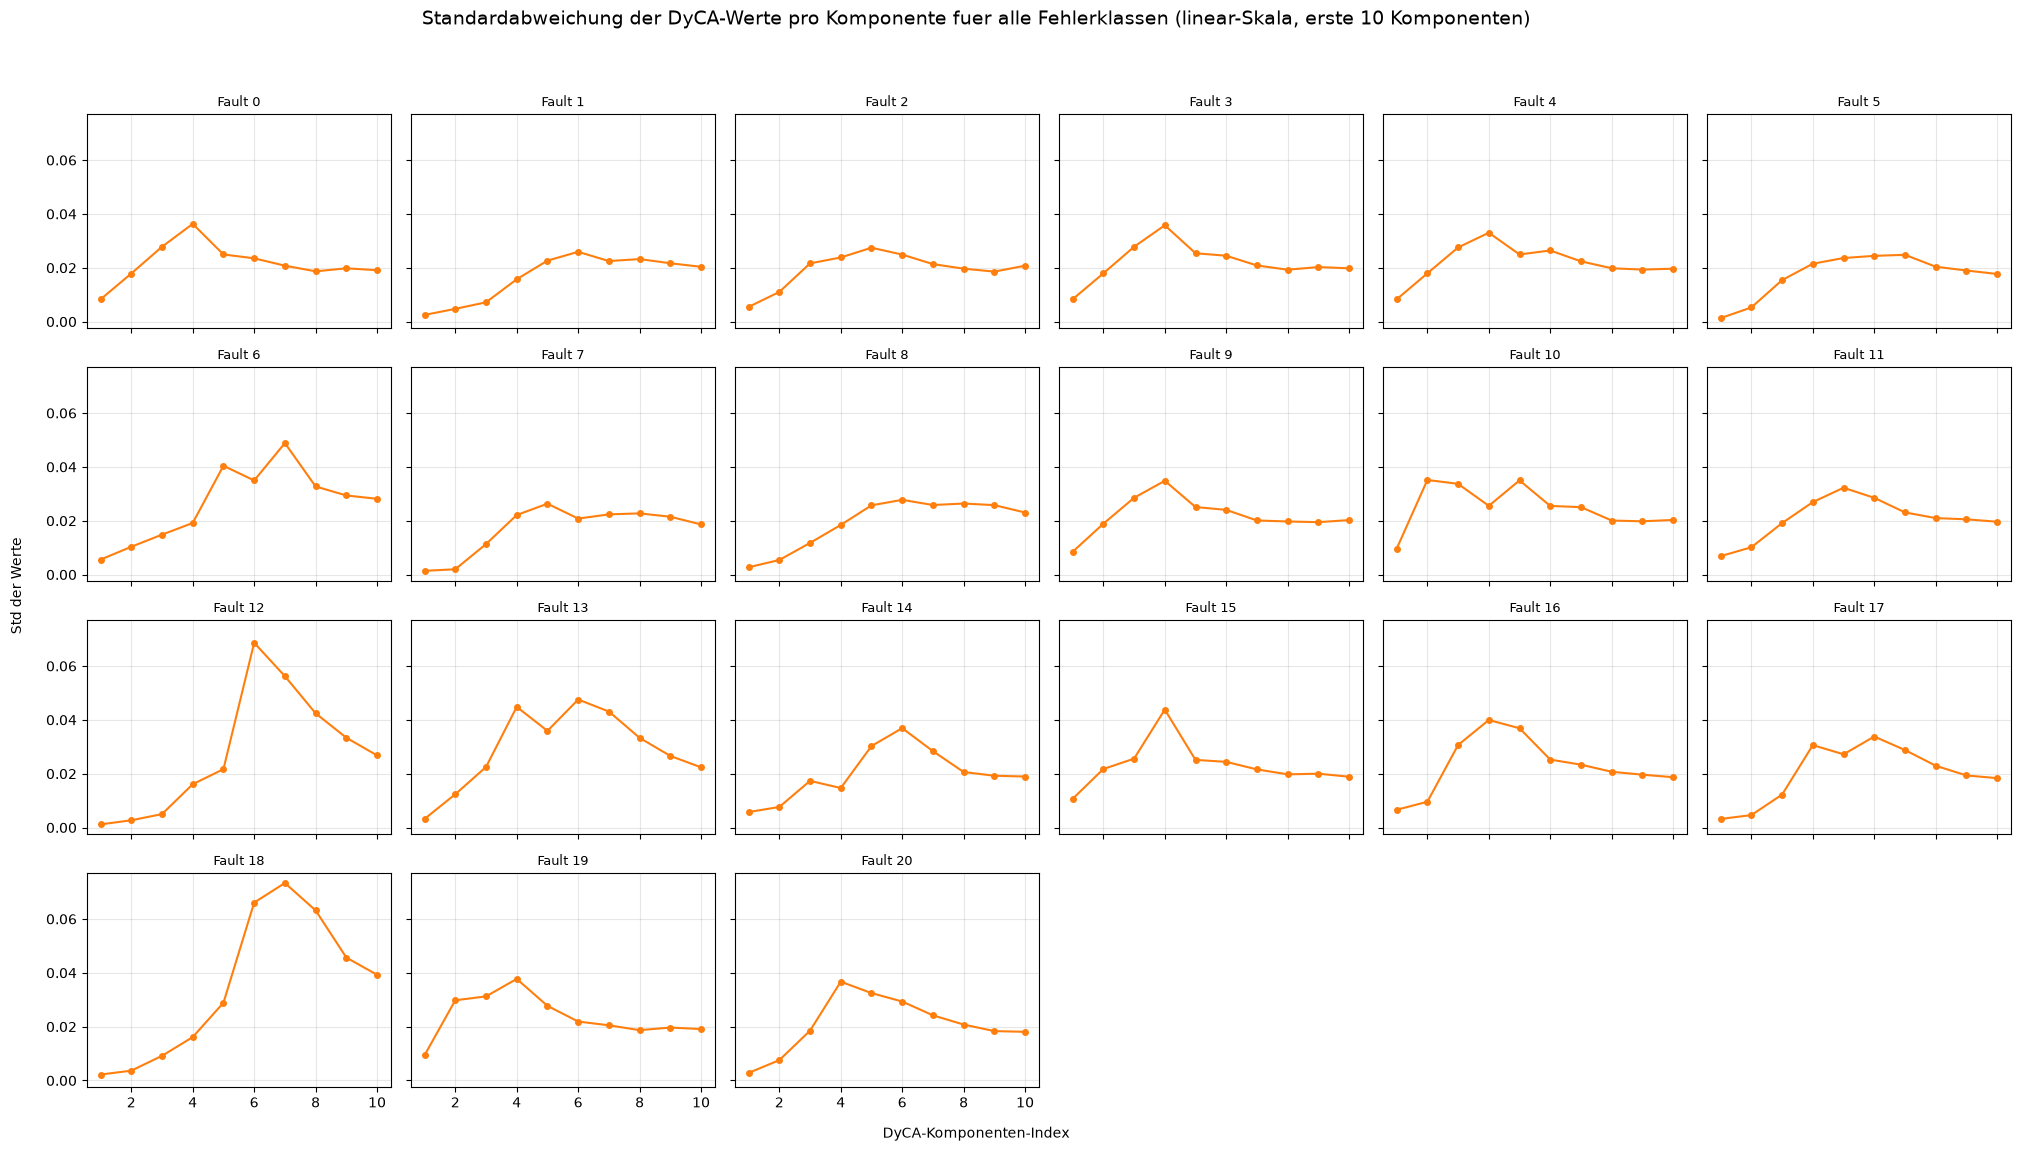

In [8]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(agg, METHOD, k_max=K_MAX)

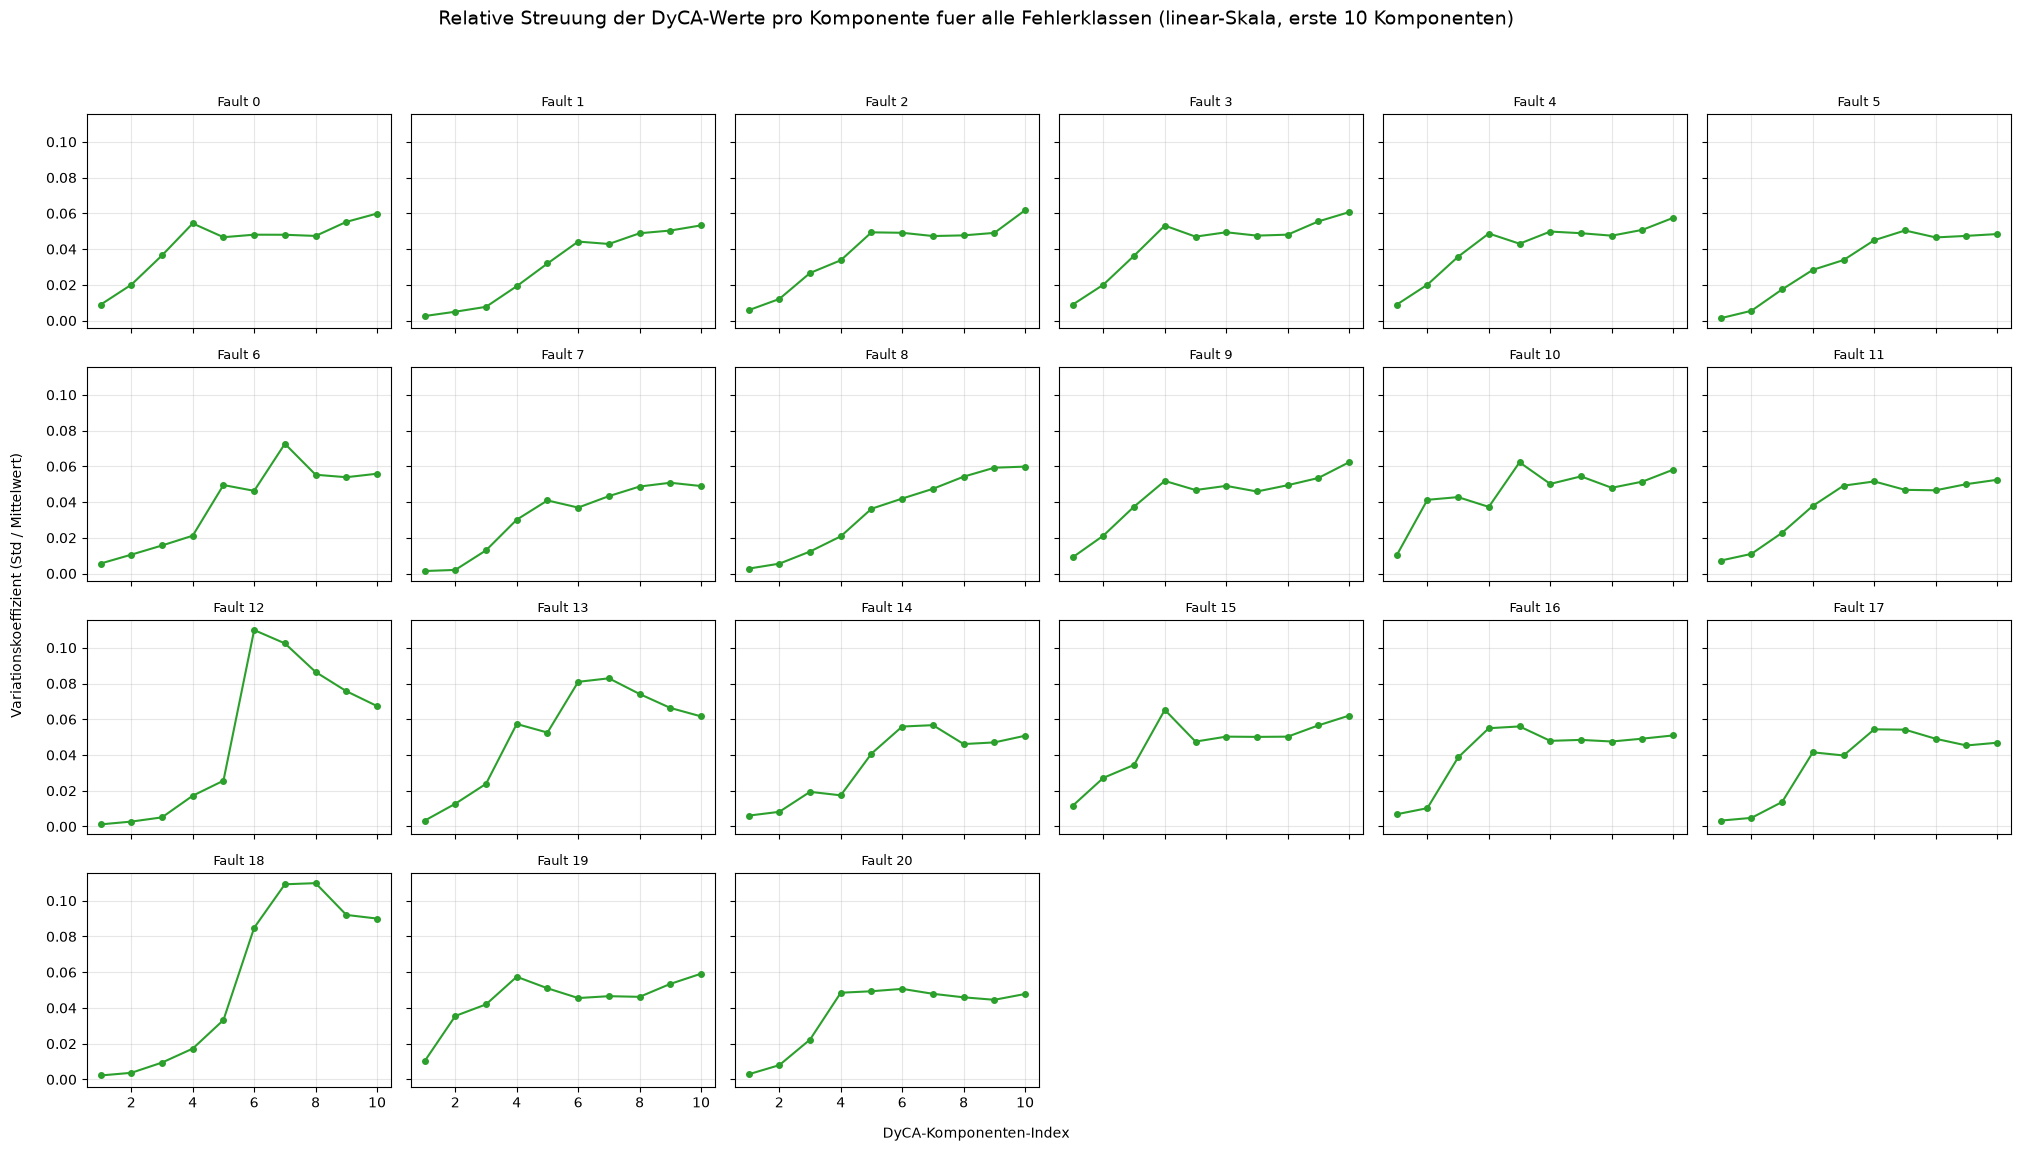

In [9]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus ueber plot_mode=... moeglich.
_ = plot_cv(agg, METHOD, k_max=K_MAX)

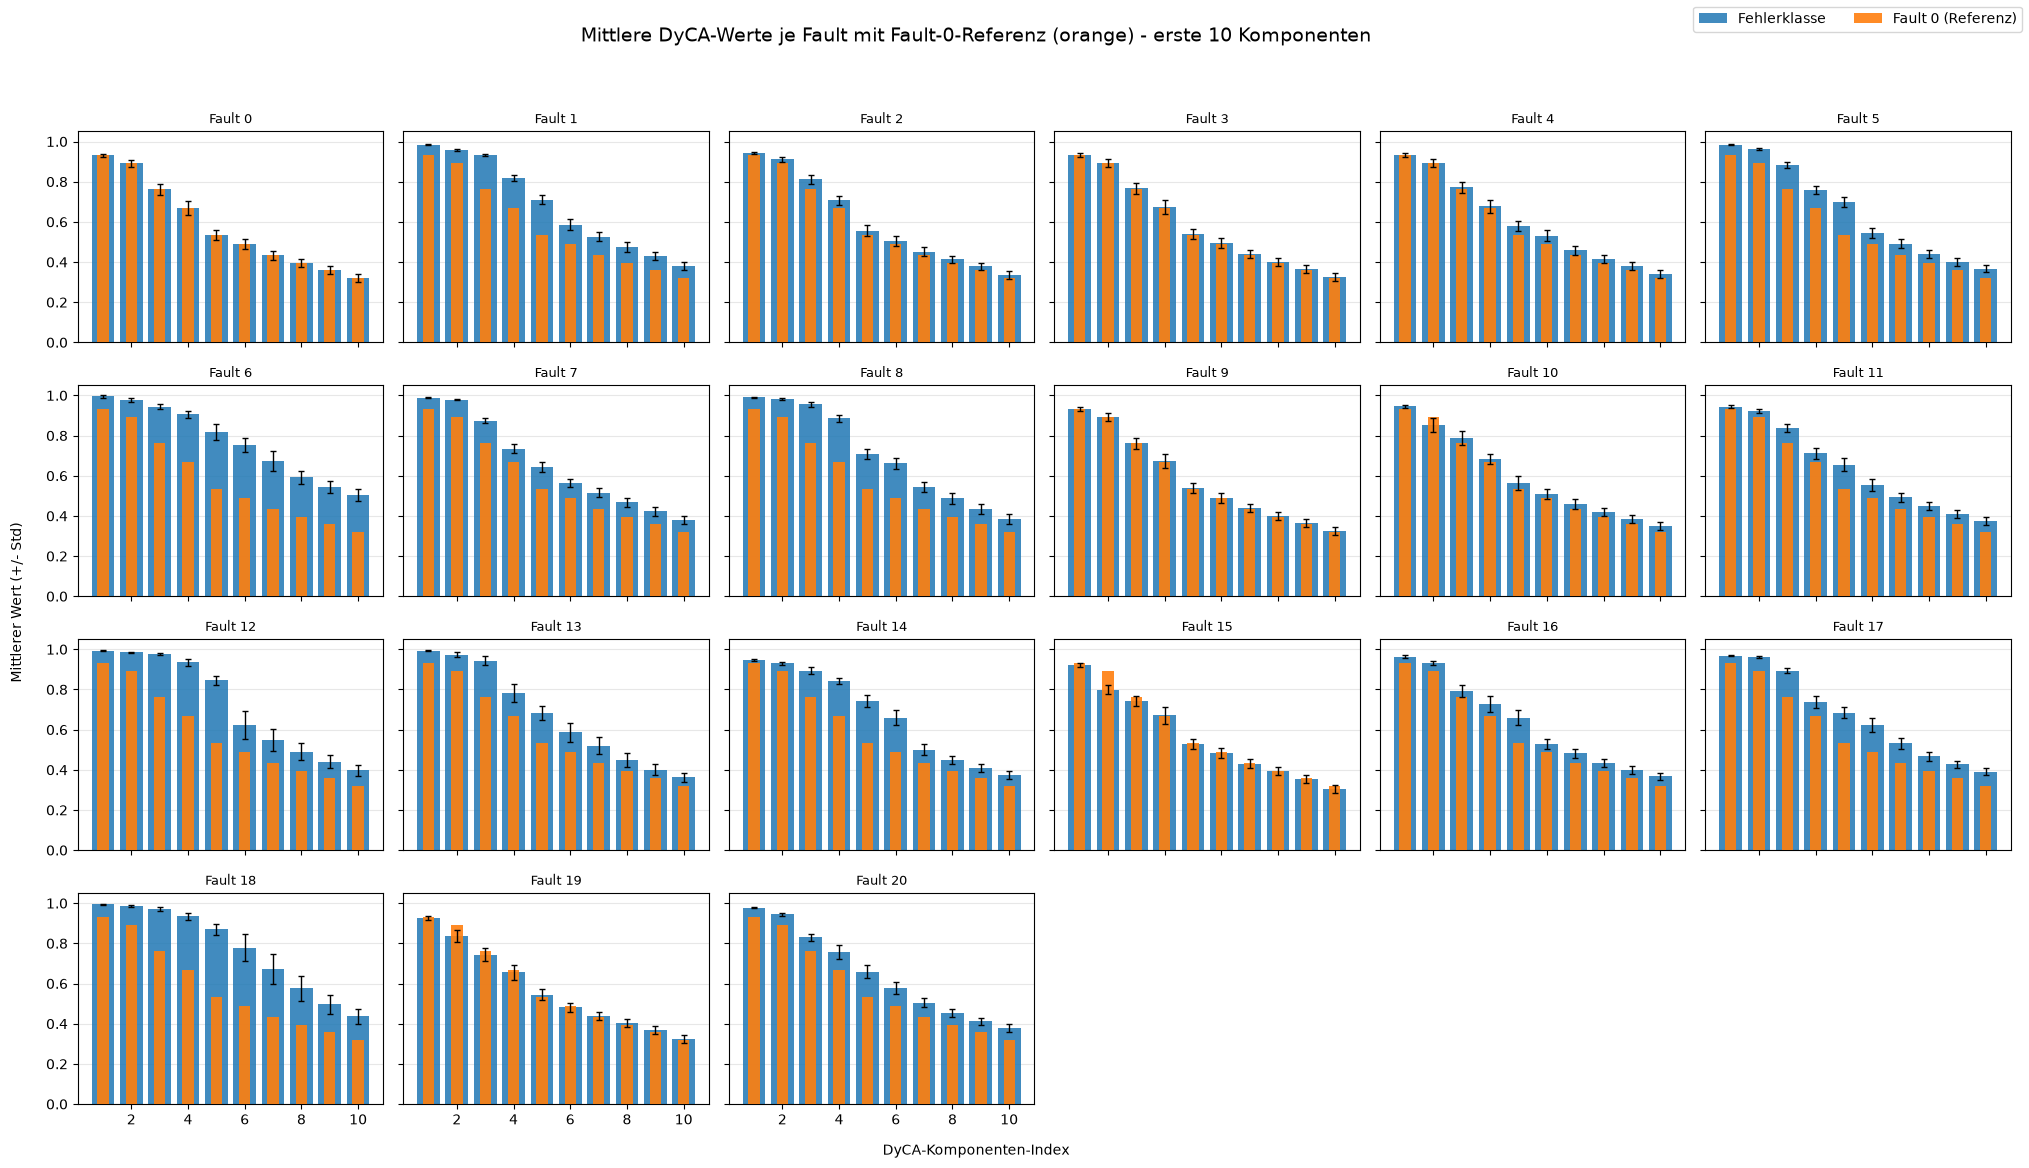

In [10]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: K_BAR.
_ = plot_bars(agg, METHOD, k_bar=K_BAR)

## Export der Trainings-Spektren

Schreibt `dyca_eigenvalues_train.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [11]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(per_run, METHOD, SCALING_MODE, DATA_DIR)

DyCA-Train gespeichert: (10073, 54) -> data_csv/dyca_eigenvalues_train.csv


'data_csv/dyca_eigenvalues_train.csv'